# DataCo Supply Chain Analysis

## Introduction
This dataset contain supply chain and e-commerce order data from DataCo Global,
covering 180,519 orders across 47 columns. The analysis explores delivery
performance, shipping profitability, regional market activity, and product
profitability to identify key business insights and operational inefficiencies.

## Dataset
- Source: Kaggle
- Records: 180,519 orders
- Format: CSV (.csv)

## Skills Used
- Python (Pandas)
- Data Visualization (Matplotlib)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DataCoSupplyChainDataset.csv to DataCoSupplyChainDataset.csv


(180519, 53)
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping d

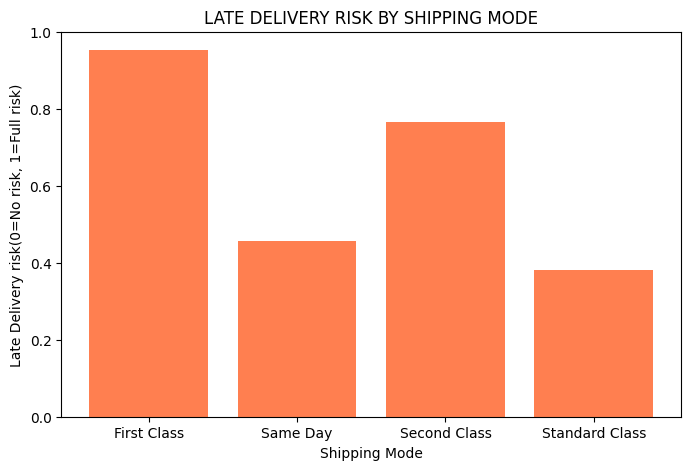

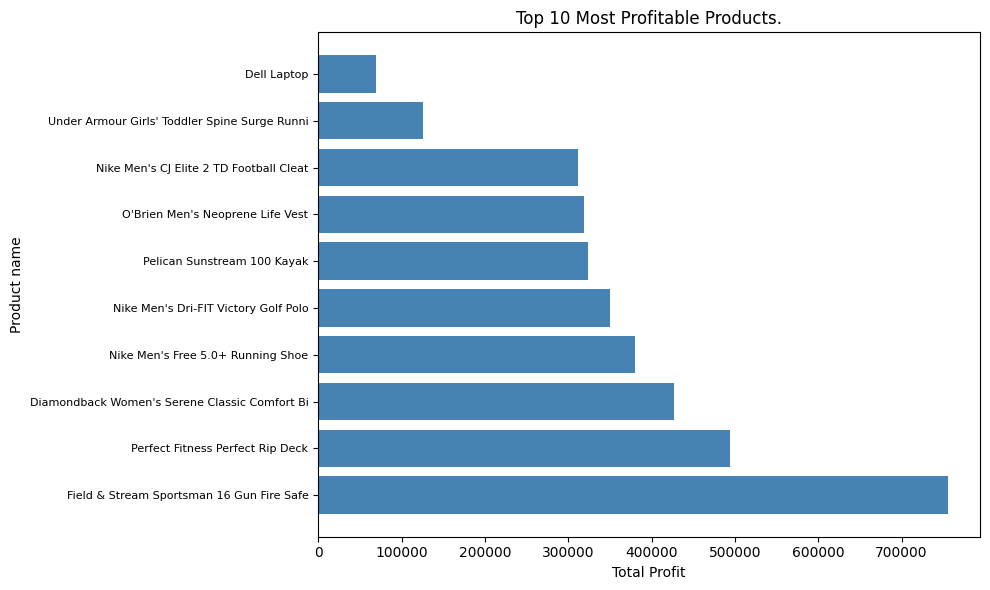

In [ ]:
#Load data
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.float_format', '{:,.0f}'.format)
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding="latin-1")



#Exploring dataset
print(df.shape)
print(df.columns.tolist())
#Drops unusable columns during analysis
drop_coln = ["Customer Email", "Customer Fname", "Customer Lname","Order Zipcode",
             "Customer Zipcode","Customer Password","Customer Street","Product Description"]
df = df.drop(columns=drop_coln)
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
print(df.dtypes)

#Clean null
#drop empty/null column
drop_empty = ["Product Description", "Order Zipcode"]

#converts dates
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

#confirm
print(df.shape)
print(df.dtypes)

#Analysis
#Qn 1.which delivery status appeared the most.
print(df["Delivery Status"].value_counts())
print(df["Late_delivery_risk"].value_counts())
#Qn 2.which Shipping mode profitable
print(df.groupby("Shipping Mode")["Order Profit Per Order"].sum().sort_values(ascending=False))
#Qn 3.Regions most orders.
print(df["Order Region"].value_counts())
#Qn 4.Product with most profit.
print(df.groupby("Product Name")["Order Profit Per Order"].sum().sort_values(ascending=False).head(10))
#n 5.Relationship between shipping mode and late delivery
print(df.groupby("Shipping Mode")["Late_delivery_risk"].mean().sort_values(ascending=False))


shipp_risk = df.groupby("Shipping Mode")["Late_delivery_risk"].mean()

plt.figure(figsize=(8,5))
plt.bar(shipp_risk.index, shipp_risk.values, color="coral")
plt.title("LATE DELIVERY RISK BY SHIPPING MODE")
plt.xlabel("Shipping Mode")
plt.ylabel("Late Delivery risk(0=No risk, 1=Full risk)")
plt.tight_layout
plt.savefig("Shipping_late_deliver_risk.png")
plt.show()

product_profit=df.groupby("Product Name")["Order Profit Per Order"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(product_profit.index, product_profit.values, color="steelblue")
plt.xlabel("Total Profit")
plt.ylabel("Product name")
plt.yticks(fontsize=8)
plt.title("Top 10 Most Profitable Products.")
plt.tight_layout()
plt.savefig("Top 10 products" ,bbox_inches="tight")
plt.show()

## Data Overview
The dataset was loaded from a CSV file containing 180,519 orders and 53 columns.
Six columns containing sensitive personal information (Customer Email, Password,
Name, and Address details) were removed, reducing the dataset to 47 columns.
Two columns with excessive missing values (Product Description and Order Zipcode)
were also dropped. Date columns were converted to datetime format to enable
delivery time calculations.

## Question 1 — Which Delivery Status Has The Highest Delivery Risk?

**Finding:**
Out of 180,519 total orders, 98,977 (over 50%) were delivered late while
41,592 arrived early, 32,196 arrived on time and 7,754 were cancelled.
This makes late delivery the most dominant delivery status, showing a
critical delivery problem in the business thus posing serious risk to
long term customer satisfaction.

## Question 2 — Which Shipping Mode is The Most Profitable?

**Finding:**
Standard Class is the most profitable shipping mode with 2,370,454 in
total profit, higher than all other modes. Second Class followed with
750,308, First Class at 643,122 and Same Day at 203,018. This suggests
that despite Standard Class being the slower option, it remains the most
profitable and cost effective shipping method for the business.

## Question 3 — Which Region Has The Most Orders?

**Finding:**
Central America leads as the biggest order region with 28,341 orders,
followed by Western Europe with 27,109 orders. Central Asia is the least
active region with only 553 orders. This indicates that Central America
and Western Europe are the company's most active markets by order frequency,
while Central Asia represents the least engaged region.

## Question 4 — Which Product Generates The Most Profit?

**Finding:**
Field & Stream Sportsman 16 Gun Fire Safe is the most profitable product,
generating 756,221 in total profit, significantly ahead of all other products.
Perfect Fitness Perfect Rip Deck followed at 493,828, while Dell Laptop
recorded the lowest profit among the top 10 at 69,657. This suggests that
outdoor and sports equipment are the company's strongest performing
product categories.

## Question 5 — Relationship Between Shipping Mode and Late Delivery

**Finding:**
First Class and Second Class shipping modes recorded a higher late delivery
risk, indicating that orders processed through these modes are more likely
to arrive late. In contrast, Same Day and Standard Class showed less late
delivery risk, suggesting better logistics management or more realistic
delivery time commitments. The company should investigate why mid-range
shipping options are consistently underperforming on delivery promises.

## Overall Summary

This analysis reveals three critical insights. First, over 50% of all orders
are delivered late, representing a major operational failure that directly
threatens customer Loyality. Second, despite being the slowest option,
Standard Class shipping is both the most profitable and most reliable mode,
while First and Second Class shipping carry higher late delivery risk and
should be urgently reviewed. Finally, Central America is the company's largest
market by order volume and Field & Stream Sportsman 16 Gun Fire Safe is the
most profitable product, suggesting that focusing on outdoor and sports
equipment in the Americas region represents the strongest growth opportunity
for the business.